# Enzymatic activity and Hamiltonian
In this notebook we will compare some of the experimental measurements that we have availible from literature and in-house experiments with the hamiltonian scores trained on different MSAs

In [217]:
from lglvae.lglvae import LGLVAE
import matplotlib.pyplot as plt
from pathlib import Path
import numpy as np
import pandas as pd
import subprocess
from dca import helper_functions as hf
import seaborn as sns
from dca import dca_class, dca_analysis, helper_functions, hmm_tools

rootDir = Path('/Users/miiijaan/Documents/MorcosLab/alphabetahydro/Q6_summer')
dataDir = rootDir / 'data'
figDir = rootDir / 'figures'
modelsDir = rootDir / 'models'
profilesDir = dataDir / 'hmmFiles'
trainingMSADir = dataDir / 'MSA_training'
specimenMSADir = dataDir / 'individuals_MSA'
path2Easel = '/Users/miiijaan/easel/miniapps/esl-reformat'

metaData = pd.read_csv(dataDir / 'Allmaps-info.csv')
metaData

EnzymeAct_df = pd.read_csv(dataDir / 'SequenceActivities.csv')
EnzymeAct_filt = EnzymeAct_df[EnzymeAct_df.iloc[:, -3:].notna().any(axis=1)]

## Aligning the individuals to the profiles

In [218]:
for row in metaData.itertuples():
    #Create the directory with the corresponding aligned sequences for each specimen
    current_alignedDir = specimenMSADir / row.abbrev
    current_alignedDir.mkdir(exist_ok=True)
    current_profile = profilesDir / f'{row.HMM_profile}'

    for currentFasta in specimenMSADir.glob('*-fullseq.fasta'):
        currentName = currentFasta.stem.split('-')[0]
        out_sto = current_alignedDir / f'{currentName}_{row.abbrev}.sto'
        subprocess.run(
            ['hmmsearch', '-A', str(out_sto), str(current_profile), str(currentFasta)],
            stdout=subprocess.DEVNULL,
            stderr=subprocess.DEVNULL,
            check=True
        )
        out_fasta = current_alignedDir / f'{currentName}_{row.abbrev}.fasta'
        subprocess.run(
            [path2Easel, '-o', str(out_fasta), 'afa', str(out_sto)],
            stdout=subprocess.DEVNULL,
            stderr=subprocess.DEVNULL,
            check=True
        )
        out_clean_fasta = current_alignedDir / f'{currentName}_{row.abbrev}_clean.fasta'
        hf.clean_pfam(out_fasta,out_clean_fasta)   

First we import the models, this have already been trained previously

In [219]:
for row in metaData.itertuples():
    #Create the directory with the corresponding aligned sequences for each specimen
    current_alignedDir = specimenMSADir / row.abbrev
    for currentFasta in specimenMSADir.glob('*-fullseq.fasta'):
        currentName = currentFasta.stem.split('-')[0]
        out_clean_fasta = current_alignedDir / f'{currentName}_{row.abbrev}_clean.fasta'

In [220]:
ThreeSeeds_Model = LGLVAE.load(modelsDir / '3SEEDS_NEWMAP.pkl')
Q6_filt8_model = LGLVAE.load(modelsDir / 'Q6-filt8.pkl')
Q6_filt10_model = LGLVAE.load(modelsDir / 'Q6-filt10.pkl')
LitPositive_Model = LGLVAE.load(modelsDir / 'filtered_5pct_ABH_LiterturePositives.pkl')
HAcD_purged_Model = LGLVAE.load(modelsDir / 'HaloacetatePurged_updated.pkl')

all_models = [ThreeSeeds_Model, LitPositive_Model,Q6_filt8_model, Q6_filt10_model, HAcD_purged_Model]

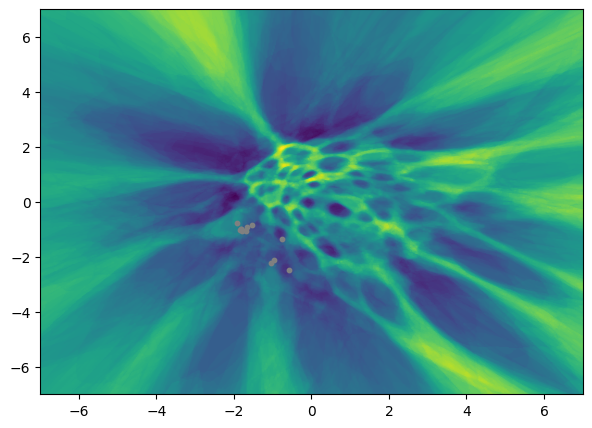

In [221]:
#To plot one of the landscapes
fig, ax = plt.subplots(1, 1, figsize=(7, 5))
im = ThreeSeeds_Model.plot_landscape(ax)
row_df = metaData[metaData['Name'] == 'Three Seeds']
for row in row_df.itertuples():
    #Create the directory with the corresponding aligned sequences for each specimen
    current_alignedDir = specimenMSADir / row.abbrev
    for currentFasta in specimenMSADir.glob('*-fullseq.fasta'):
        currentName = currentFasta.stem.split('-')[0]
        out_clean_fasta = current_alignedDir / f'{currentName}_{row.abbrev}_clean.fasta'
        current_sequence = ThreeSeeds_Model.encode_sequences(out_clean_fasta)
        ax.scatter(current_sequence[:, 0], current_sequence[:, 1], s=10, color="gray", zorder=40,label=currentName)


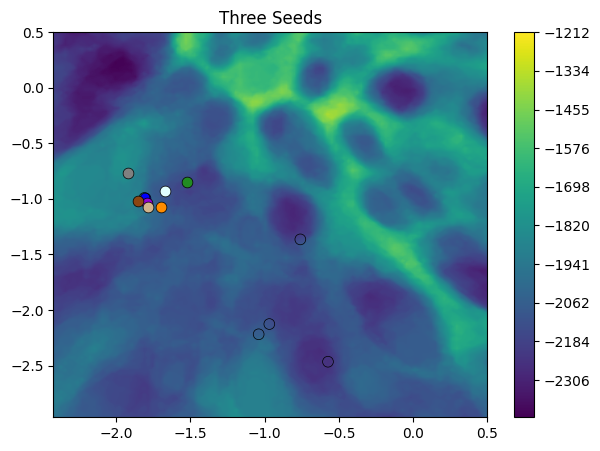

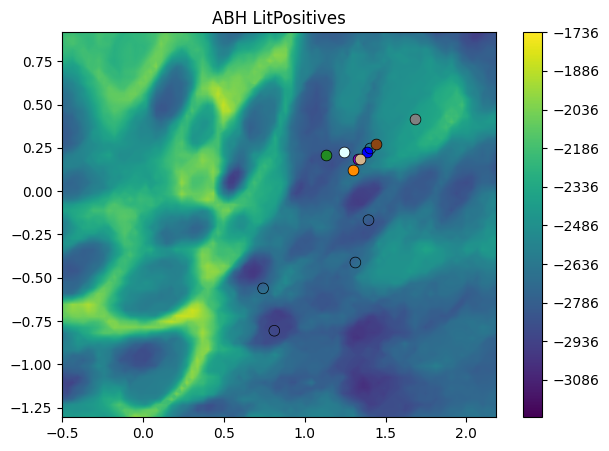

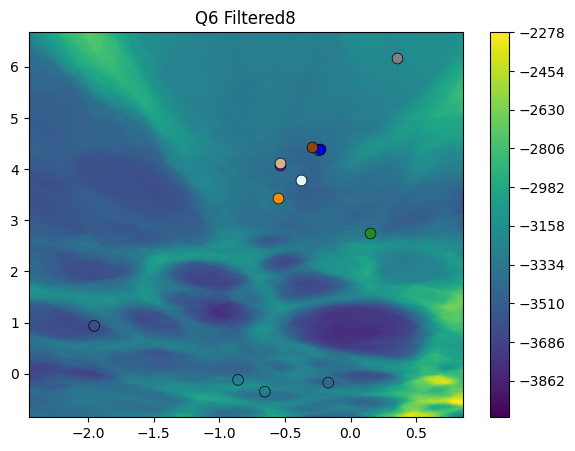

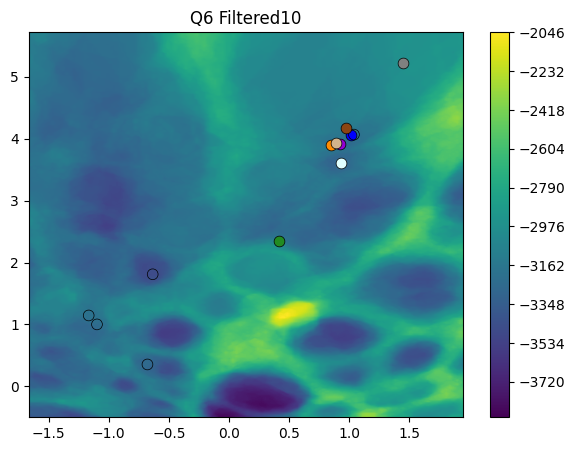

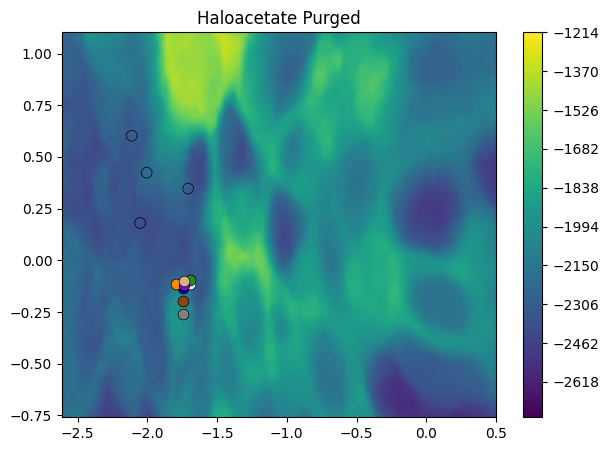

In [222]:
for row, model in zip(metaData.itertuples(), all_models):
    fig, ax = plt.subplots(1, 1, figsize=(7, 5))
    im = model.plot_landscape(ax)
    plt.colorbar(im)
    current_alignedDir = specimenMSADir / row.abbrev
    maxX, maxY = 0, 0
    minX, minY = 0, 0
    for currentFasta in specimenMSADir.glob('*-fullseq.fasta'):
        currentName = currentFasta.stem.split('-')[0]
        out_clean_fasta = current_alignedDir / f'{currentName}_{row.abbrev}_clean.fasta'
        current_sequence = model.encode_sequences(out_clean_fasta)
        maxX = max(maxX, current_sequence[:, 0].max())
        maxY = max(maxY, current_sequence[:, 1].max())
        minX = min(minX, current_sequence[:, 0].min())
        minY = min(minY, current_sequence[:, 1].min())
        color= EnzymeAct_df.loc[EnzymeAct_df['Protein ID'] == currentName, f'color'].values
        plt.scatter(current_sequence[:, 0], current_sequence[:, 1], s=60, zorder=40,label=currentName, edgecolors='black',linewidths=0.5, color=color)
    handles, labels = ax.get_legend_handles_labels()
    #ax.legend(handles, labels, bbox_to_anchor=(1.5, 1), loc='upper left', fontsize='small', borderaxespad=0.0)
    plt.title(row.Name)
    plt.xlim(minX-0.5, maxX + 0.5)
    plt.ylim(minY -0.5, maxY + 0.5)
    plt.savefig(figDir / f'{row.abbrev}_landscape_zoom.png', dpi=300)




In [223]:
for row, model in zip(metaData.itertuples(), all_models):
    ham_list = []
    for prot in EnzymeAct_filt['Protein ID']:
        prot_id = str(prot).strip()
        fasta_path = specimenMSADir / row.abbrev / f"{prot_id}_{row.abbrev}_clean.fasta"
        try:
            ham = model.DCA.compute_Hamiltonian(str(fasta_path))[0][0]
        except Exception:
            ham = np.nan
        ham_list.append(ham)

    EnzymeAct_filt[f'Ham_{row.abbrev}'] = ham_list

In [224]:
EnzymeAct_df

,Protein ID,In lab,Notes,In UniProt,Organism,Protein,FAcD Activity,TTN,TTN_error,color
0,Q1JU72,No,Literature Positive,UniProt Reviewed,Burkholderia sp,Fluoroacetate dehalogenase,NaN,NaN,NaN,black
1,Q6NAM1,Yes,Literature Positive,UniProt Reviewed,Rhodopseudomonas palustris (strain ATCC BAA-98...,Fluoroacetate dehalogenase,Fast,22176.0,1102.0,red
2,Q01398,No,Literature Positive,UniProt Reviewed,Moraxella sp. (strain B),Haloacetate dehalogenase H-1,NaN,NaN,NaN,aqua
3,Q123C8,No,Literature Positive,UniProt Obsolete Unreviewed,Polaromonas sp. (strain JS666 / ATCC BAA-500),Alpha/beta hydrolase fold protein,NaN,NaN,NaN,fuchsia
4,Q479B8,Yes,Literature Positive,UniProt Active Unreviewed,Dechloromonas aromatica (strain RCB),Alpha/beta hydrolase fold protein,Fast,NaN,NaN,lime
5,Q8Z0Q1,No,Literature Positive,UniProt Obsolete Unreviewed,Nostoc sp. (strain PCC 7120 / SAG 25.82 / UTEX...,Alr0039 protein,NaN,NaN,NaN,plum
6,A0A0D7E0W8,Yes,Q6 LGL2 initial enzyme; closest purifyable extant,UniProt Active Unreviewed,Rhodopseudomonas palustris,Alpha/beta hydrolase,Slow,NaN,NaN,saddlebrown
7,A0A1W6ZS72,Yes,Q6 LGL2 follow-up enzyme; extant well,UniProt Active Unreviewed,Pseudorhodoplanes sinuspersici,Alpha/beta hydrolase,Fast,NaN,NaN,lightcyan
8,A0A7S9CV34,Yes,Q6 LGL2 follow-up enzyme; extant barrier with ...,UniProt Obsolete Unreviewed,Bradyrhizobium genosp. L.,Alpha/beta hydrolase,Slow,NaN,NaN,gray
9,A0A4V6IMR0,Yes,LGL1 Extant from training set,UniProt Active Unreviewed,Methylocella tundrae,Fluoroacetate dehalogenase,Fast,5671.0,128.0,forestgreen


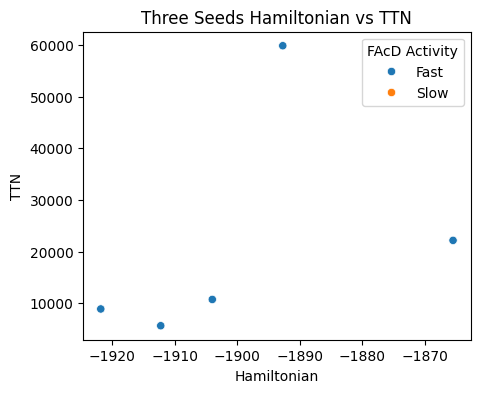

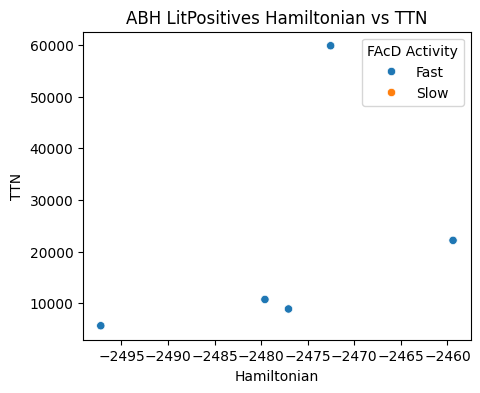

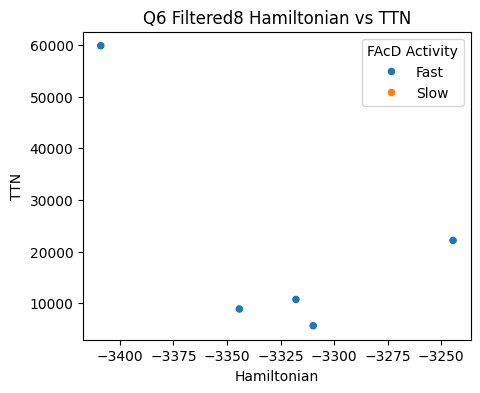

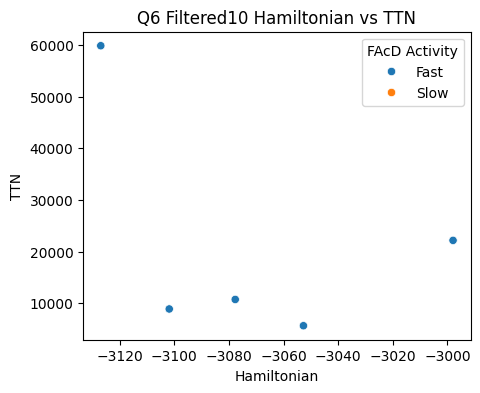

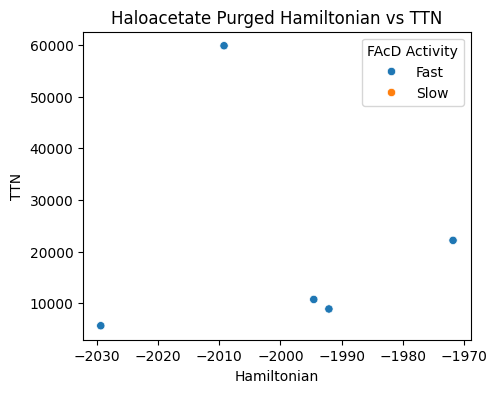

In [279]:
for row in metaData.itertuples():
    ham_col = f'Ham_{row.abbrev}'
    if ham_col in EnzymeAct_filt.columns:
        plt.figure(figsize=(5, 4))
        color= EnzymeAct_df.loc[EnzymeAct_df['Protein ID'] == currentName, f'color'].values
        sns.scatterplot(data=EnzymeAct_filt, x=ham_col, y='TTN', hue='FAcD Activity')
        plt.title(f'{row.Name} Hamiltonian vs TTN')
        plt.xlabel('Hamiltonian')
        plt.ylabel('TTN')


Plotting Scatter plots of Hamiltonan values vs. FAcD activity

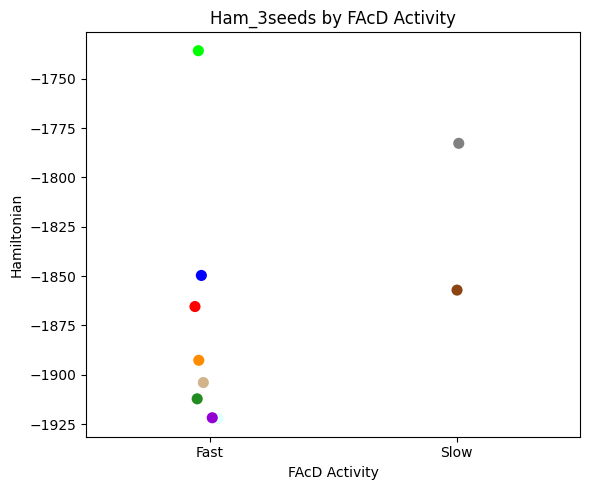

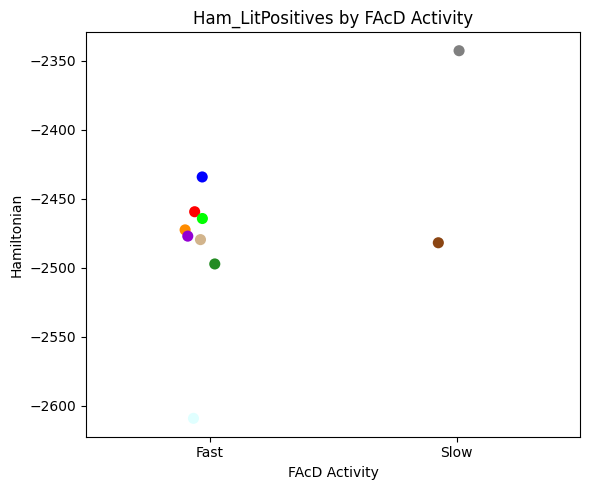

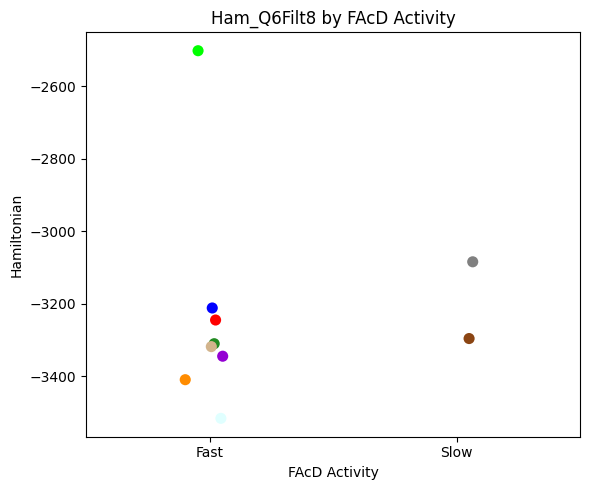

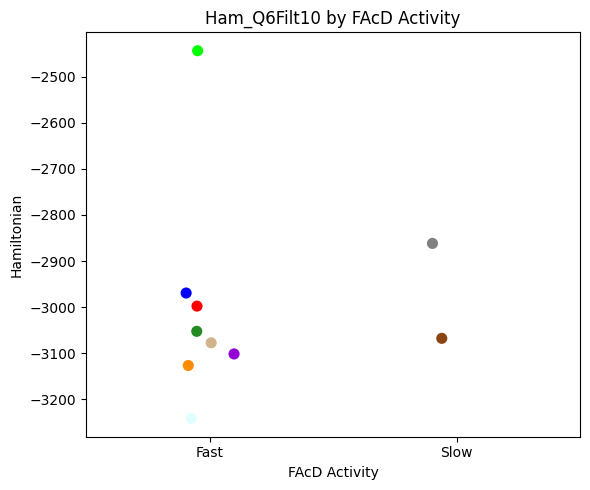

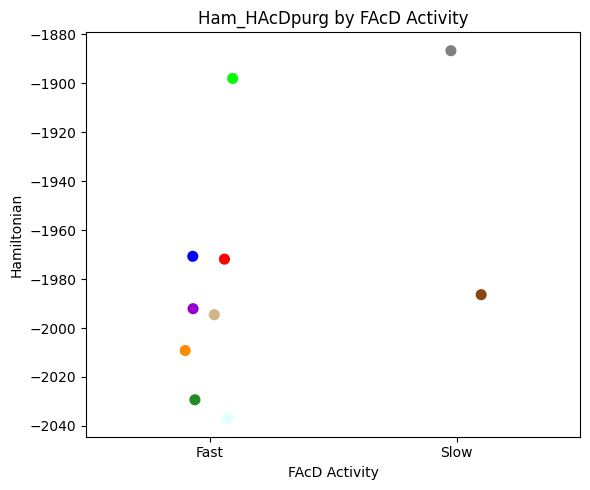

In [226]:
ham_cols = [col for col in EnzymeAct_filt.columns if col.startswith('Ham_')]


for ham_col in ham_cols:
    plot_data_col = EnzymeAct_filt[['FAcD Activity', ham_col,'color']].dropna()
    color= EnzymeAct_df.loc[EnzymeAct_df['Protein ID'] == currentName, f'color'].values

    custom_palette = {c:c for c in plot_data_col['color'].unique()}
    plt.figure(figsize=(6, 5))

    sns.stripplot(
        data=plot_data_col,
        x='FAcD Activity',
        y=ham_col,
        hue= 'color',
        size=8,
        legend= False,
        palette=custom_palette
    )

    plt.title(f'{ham_col} by FAcD Activity')
    plt.xlabel('FAcD Activity')
    plt.ylabel('Hamiltonian')
    plt.tight_layout()
plot_data = EnzymeAct_filt.melt(
    id_vars=['FAcD Activity'],
    value_vars=ham_cols,
    var_name='Model',
    value_name='Hamiltonian'
).dropna(subset=['FAcD Activity', 'Hamiltonian'])
plt.show()




How to prepare your DI pair for connectivity map

In [135]:
Q6_hmm = profilesDir / 'Q6NAM1.hmm'
Q6_seed = profilesDir / 'Q6NAM1_seed.fasta'

ranked_DI_pairs_Q6filt8 = Q6_filt8_model.DCA.DI[ np.argsort( Q6_filt8_model.DCA.DI[:,2] )[::-1] ]
alignment_dictionary_Q6filt8 = hmm_tools.MapSeq2hmmProfile(str(Q6_hmm), str(Q6_seed))
mapped_di_pairs_Q6filt8 = dca_analysis.map_filter_DIpairs(alignment_dictionary_Q6filt8, ranked_DI_pairs_Q6filt8)

In [136]:
Q6_hmm = profilesDir / 'Q6NAM1.hmm'
Q6_seed = profilesDir / 'Q6NAM1_seed.fasta'

ranked_DI_pairs_Q6filt10 = Q6_filt10_model.DCA.DI[ np.argsort( Q6_filt10_model.DCA.DI[:,2] )[::-1] ]
alignment_dictionary_Q6filt10 = hmm_tools.MapSeq2hmmProfile(str(Q6_hmm), str(Q6_seed))
mapped_di_pairs_Q6filt10 = dca_analysis.map_filter_DIpairs(alignment_dictionary_Q6filt10, ranked_DI_pairs_Q6filt10)

In [137]:
LitPositive_hmm = profilesDir / 'ABH_LiterturePositives_FullSeq_muscle.hmm'
Q6_seed = profilesDir / 'Q6NAM1_seed.fasta'

ranked_DI_pairs_LitPositive = LitPositive_Model.DCA.DI[ np.argsort(LitPositive_Model.DCA.DI[:,2] )[::-1] ]
alignment_dictionary_LitPositive = hmm_tools.MapSeq2hmmProfile(str(LitPositive_hmm), str(Q6_seed))
mapped_di_pairs_LitPositive = dca_analysis.map_filter_DIpairs(alignment_dictionary_LitPositive, ranked_DI_pairs_LitPositive)

In [145]:
Threeseeds_hmm = profilesDir / '3seeds.hmm'
Q6_seed = profilesDir / 'Q6NAM1_seed.fasta'

ranked_DI_pairs_ThreeSeeds = ThreeSeeds_Model.DCA.DI[ np.argsort( ThreeSeeds_Model.DCA.DI[:,2] )[::-1] ]
alignment_dictionary_ThreeSeeds = hmm_tools.MapSeq2hmmProfile(str(Threeseeds_hmm), str(Q6_seed))
mapped_di_pairs_ThreeSeeds = dca_analysis.map_filter_DIpairs(alignment_dictionary_ThreeSeeds, ranked_DI_pairs_ThreeSeeds)

In [146]:
HAcDPurged_hmm = profilesDir / 'Haloacetate_purged_PF00561.hmm'
Q6_seed = profilesDir / 'Q6NAM1_seed.fasta'

ranked_DI_pairs_HAcDPurged = HAcD_purged_Model.DCA.DI[ np.argsort( HAcD_purged_Model.DCA.DI[:,2] )[::-1] ]
alignment_dictionary_HAcDPurged = hmm_tools.MapSeq2hmmProfile(str(HAcDPurged_hmm), str(Q6_seed))
mapped_di_pairs_HAcDPurged = dca_analysis.map_filter_DIpairs(alignment_dictionary_HAcDPurged, ranked_DI_pairs_HAcDPurged)

How to plot the Connectivity Map

In [267]:
import pandas as pd
import numpy as np
import py4cytoscape as cy

top_n = 100 
di_data = mapped_di_pairs_HAcDPurged[:top_n]

# 1. Build your base edge list dataframe
edge_list = pd.DataFrame({
    'source': [str(int(float(row[0]))) for row in di_data], 
    'target': [str(int(float(row[1]))) for row in di_data], 
    'interaction': 'coevolution',                   
    'DI_score': [float(row[2]) for row in di_data]  
})

# 2. PYTHON-SIDE MATH: Normalize and scale DI scores straight to line thicknesses
# This scales your DI values into a clean thickness range from 1.5 (weakest) to 10.0 (strongest)
min_di = edge_list['DI_score'].min()
max_di = edge_list['DI_score'].max()

if max_di != min_di:
    edge_list['calculated_width'] = 1.5 + 8.5 * (edge_list['DI_score'] - min_di) / (max_di - min_di)
else:
    edge_list['calculated_width'] = 4.0  # Safe fallback if all scores are identical

print("Connecting to Cytoscape...")
network_suid = cy.create_network_from_data_frames(
    edges=edge_list, 
    title="HAcDPurged DI Network", 
    collection="Protein Coevolution"
)

# -------------------------------------------------------------------------
# Step 3: Design the Visual Style
# -------------------------------------------------------------------------
style_name = "CoevolutionStyle"

try:
    cy.create_visual_style(style_name)
except:
    pass 
cy.set_visual_style(style_name)

# Node defaults
cy.set_node_shape_default('ellipse', style_name=style_name)
cy.set_node_size_default(80, style_name=style_name)               
cy.set_node_font_size_default(15, style_name=style_name)          
cy.set_node_color_default("#E6E61D", style_name=style_name)       
cy.set_node_border_width_default(1.5, style_name=style_name)
cy.set_node_border_color_default('#37474F', style_name=style_name) 
cy.set_node_label_mapping('name', style_name=style_name) 

# --- FIXED: Direct Passthrough Mapping ---
# We tell Cytoscape to read the raw thickness values we computed in Python
cy.set_edge_line_width_mapping(
    table_column='calculated_width',
    mapping_type='p', # 'p' stands for Passthrough mapping (direct values)
    style_name=style_name
)

cy.set_edge_color_default('#2C3E50', style_name=style_name)

# -------------------------------------------------------------------------
# Step 4: Layout Strategy
# -------------------------------------------------------------------------
cy.layout_network(layout_name='force-directed', network=network_suid)
print("Network successfully rendered in Cytoscape desktop!")

# -------------------------------------------------------------------------
# Step 5: Highlight Specific Target Residues (Loop-safe)
# -------------------------------------------------------------------------
highlight_residues = ['110', '280', '111', '114', '134', '155', '156', '219']

if highlight_residues:
    existing_nodes = cy.get_all_nodes()
    valid_targets = [str(r) for r in highlight_residues if str(r) in existing_nodes]
    
    if valid_targets:
        print(f"Successfully coloring present target residues: {valid_targets}")
        cy.clear_selection()
        
        for node_id in valid_targets:
            for node_id in valid_targets:
                cy.set_node_color_bypass(node_id, '#FF5722')
                cy.set_node_size_bypass(node_id, 120)
            for node_id in valid_targets:
                cy.set_node_color_bypass(node_id, '#FF5722')
                cy.set_node_size_bypass(node_id, 120)
        
        cy.set_visual_style(style_name)
        # py4cytoscape has no update_style(); reapply the visual style if needed
        cy.set_visual_style(style_name)
        cy.clear_selection()


Connecting to Cytoscape...
Applying default style...
Applying preferred layout
Network successfully rendered in Cytoscape desktop!
Successfully coloring present target residues: ['110', '280', '111', '134', '219']


In [266]:


import pandas as pd
import numpy as np
import py4cytoscape as cy

top_n = 100 
di_data = mapped_di_pairs_ThreeSeeds[:top_n]

# 1. Build your base edge list dataframe
edge_list = pd.DataFrame({
    'source': [str(int(float(row[0]))) for row in di_data], 
    'target': [str(int(float(row[1]))) for row in di_data], 
    'interaction': 'coevolution',                   
    'DI_score': [float(row[2]) for row in di_data]  
})

# 2. PYTHON-SIDE MATH: Normalize and scale DI scores straight to line thicknesses
# This scales your DI values into a clean thickness range from 1.5 (weakest) to 10.0 (strongest)
min_di = edge_list['DI_score'].min()
max_di = edge_list['DI_score'].max()

if max_di != min_di:
    edge_list['calculated_width'] = 1.5 + 8.5 * (edge_list['DI_score'] - min_di) / (max_di - min_di)
else:
    edge_list['calculated_width'] = 4.0  # Safe fallback if all scores are identical

print("Connecting to Cytoscape...")
network_suid = cy.create_network_from_data_frames(
    edges=edge_list, 
    title="ThreeSeeds DI Network", 
    collection="Protein Coevolution"
)

# -------------------------------------------------------------------------
# Step 3: Design the Visual Style
# -------------------------------------------------------------------------
style_name = "CoevolutionStyle"

try:
    cy.create_visual_style(style_name)
except:
    pass 
cy.set_visual_style(style_name)

# Node defaults
cy.set_node_shape_default('ellipse', style_name=style_name)
cy.set_node_size_default(80, style_name=style_name)               
cy.set_node_font_size_default(15, style_name=style_name)          
cy.set_node_color_default("#E6E61D", style_name=style_name)       
cy.set_node_border_width_default(1.5, style_name=style_name)
cy.set_node_border_color_default('#37474F', style_name=style_name) 
cy.set_node_label_mapping('name', style_name=style_name) 

# --- FIXED: Direct Passthrough Mapping ---
# We tell Cytoscape to read the raw thickness values we computed in Python
cy.set_edge_line_width_mapping(
    table_column='calculated_width',
    mapping_type='p', # 'p' stands for Passthrough mapping (direct values)
    style_name=style_name
)

cy.set_edge_color_default('#2C3E50', style_name=style_name)

# -------------------------------------------------------------------------
# Step 4: Layout Strategy
# -------------------------------------------------------------------------
cy.layout_network(layout_name='force-directed', network=network_suid)
print("Network successfully rendered in Cytoscape desktop!")

# -------------------------------------------------------------------------
# Step 5: Highlight Specific Target Residues (Loop-safe)
# -------------------------------------------------------------------------
highlight_residues = ['110', '280', '111', '114', '134', '155', '156', '219']

if highlight_residues:
    existing_nodes = cy.get_all_nodes()
    valid_targets = [str(r) for r in highlight_residues if str(r) in existing_nodes]
    
    if valid_targets:
        print(f"Successfully coloring present target residues: {valid_targets}")
        cy.clear_selection()
        
        for node_id in valid_targets:
            for node_id in valid_targets:
                cy.set_node_color_bypass(node_id, '#FF5722')
                cy.set_node_size_bypass(node_id, 120)
            for node_id in valid_targets:
                cy.set_node_color_bypass(node_id, '#FF5722')
                cy.set_node_size_bypass(node_id, 120)
        
        cy.set_visual_style(style_name)
        # py4cytoscape has no update_style(); reapply the visual style if needed
        cy.set_visual_style(style_name)
        cy.clear_selection()

Connecting to Cytoscape...
Applying default style...
Applying preferred layout
Network successfully rendered in Cytoscape desktop!
Successfully coloring present target residues: ['110', '280', '111', '114', '134', '155', '156', '219']


In [265]:

import pandas as pd
import numpy as np
import py4cytoscape as cy

top_n = 100 
di_data = mapped_di_pairs_LitPositive[:top_n]

# 1. Build your base edge list dataframe
edge_list = pd.DataFrame({
    'source': [str(int(float(row[0]))) for row in di_data], 
    'target': [str(int(float(row[1]))) for row in di_data], 
    'interaction': 'coevolution',                   
    'DI_score': [float(row[2]) for row in di_data]  
})

# 2. PYTHON-SIDE MATH: Normalize and scale DI scores straight to line thicknesses
# This scales your DI values into a clean thickness range from 1.5 (weakest) to 10.0 (strongest)
min_di = edge_list['DI_score'].min()
max_di = edge_list['DI_score'].max()

if max_di != min_di:
    edge_list['calculated_width'] = 1.5 + 8.5 * (edge_list['DI_score'] - min_di) / (max_di - min_di)
else:
    edge_list['calculated_width'] = 4.0  # Safe fallback if all scores are identical

print("Connecting to Cytoscape...")
network_suid = cy.create_network_from_data_frames(
    edges=edge_list, 
    title="LitPositive DI Network", 
    collection="Protein Coevolution"
)

# -------------------------------------------------------------------------
# Step 3: Design the Visual Style
# -------------------------------------------------------------------------
style_name = "CoevolutionStyle"

try:
    cy.create_visual_style(style_name)
except:
    pass 
cy.set_visual_style(style_name)

# Node defaults
cy.set_node_shape_default('ellipse', style_name=style_name)
cy.set_node_size_default(80, style_name=style_name)               
cy.set_node_font_size_default(15, style_name=style_name)          
cy.set_node_color_default("#E6E61D", style_name=style_name)       
cy.set_node_border_width_default(1.5, style_name=style_name)
cy.set_node_border_color_default('#37474F', style_name=style_name) 
cy.set_node_label_mapping('name', style_name=style_name) 

# --- FIXED: Direct Passthrough Mapping ---
# We tell Cytoscape to read the raw thickness values we computed in Python
cy.set_edge_line_width_mapping(
    table_column='calculated_width',
    mapping_type='p', # 'p' stands for Passthrough mapping (direct values)
    style_name=style_name
)

cy.set_edge_color_default('#2C3E50', style_name=style_name)

# -------------------------------------------------------------------------
# Step 4: Layout Strategy
# -------------------------------------------------------------------------
cy.layout_network(layout_name='force-directed', network=network_suid)
print("Network successfully rendered in Cytoscape desktop!")

# -------------------------------------------------------------------------
# Step 5: Highlight Specific Target Residues (Loop-safe)
# -------------------------------------------------------------------------
highlight_residues = ['110', '280', '111', '114', '134', '155', '156', '219']

if highlight_residues:
    existing_nodes = cy.get_all_nodes()
    valid_targets = [str(r) for r in highlight_residues if str(r) in existing_nodes]
    
    if valid_targets:
        print(f"Successfully coloring present target residues: {valid_targets}")
        cy.clear_selection()
        
        for node_id in valid_targets:
            for node_id in valid_targets:
                cy.set_node_color_bypass(node_id, '#FF5722')
                cy.set_node_size_bypass(node_id, 120)
            for node_id in valid_targets:
                cy.set_node_color_bypass(node_id, '#FF5722')
                cy.set_node_size_bypass(node_id, 120)
        
        cy.set_visual_style(style_name)
        # py4cytoscape has no update_style(); reapply the visual style if needed
        cy.set_visual_style(style_name)
        cy.clear_selection()

Connecting to Cytoscape...
Applying default style...
Applying preferred layout
Network successfully rendered in Cytoscape desktop!
Successfully coloring present target residues: ['110', '280', '111', '114', '134', '219']


In [264]:
import pandas as pd
import numpy as np
import py4cytoscape as cy

top_n = 100 
di_data = mapped_di_pairs_Q6filt8[:top_n]

# 1. Build your base edge list dataframe
edge_list = pd.DataFrame({
    'source': [str(int(float(row[0]))) for row in di_data], 
    'target': [str(int(float(row[1]))) for row in di_data], 
    'interaction': 'coevolution',                   
    'DI_score': [float(row[2]) for row in di_data]  
})

# 2. PYTHON-SIDE MATH: Normalize and scale DI scores straight to line thicknesses
# This scales your DI values into a clean thickness range from 1.5 (weakest) to 10.0 (strongest)
min_di = edge_list['DI_score'].min()
max_di = edge_list['DI_score'].max()

if max_di != min_di:
    edge_list['calculated_width'] = 1.5 + 8.5 * (edge_list['DI_score'] - min_di) / (max_di - min_di)
else:
    edge_list['calculated_width'] = 4.0  # Safe fallback if all scores are identical

print("Connecting to Cytoscape...")
network_suid = cy.create_network_from_data_frames(
    edges=edge_list, 
    title="Q6filt8 DI Network", 
    collection="Protein Coevolution"
)

# -------------------------------------------------------------------------
# Step 3: Design the Visual Style
# -------------------------------------------------------------------------
style_name = "CoevolutionStyle"

try:
    cy.create_visual_style(style_name)
except:
    pass 
cy.set_visual_style(style_name)

# Node defaults
cy.set_node_shape_default('ellipse', style_name=style_name)
cy.set_node_size_default(80, style_name=style_name)               
cy.set_node_font_size_default(15, style_name=style_name)          
cy.set_node_color_default("#E6E61D", style_name=style_name)       
cy.set_node_border_width_default(1.5, style_name=style_name)
cy.set_node_border_color_default('#37474F', style_name=style_name) 
cy.set_node_label_mapping('name', style_name=style_name) 

# --- FIXED: Direct Passthrough Mapping ---
# We tell Cytoscape to read the raw thickness values we computed in Python
cy.set_edge_line_width_mapping(
    table_column='calculated_width',
    mapping_type='p', # 'p' stands for Passthrough mapping (direct values)
    style_name=style_name
)

cy.set_edge_color_default('#2C3E50', style_name=style_name)

# -------------------------------------------------------------------------
# Step 4: Layout Strategy
# -------------------------------------------------------------------------
cy.layout_network(layout_name='force-directed', network=network_suid)
print("Network successfully rendered in Cytoscape desktop!")

# -------------------------------------------------------------------------
# Step 5: Highlight Specific Target Residues (Loop-safe)
# -------------------------------------------------------------------------
highlight_residues = ['110', '280', '111', '114', '134', '155', '156', '219']

if highlight_residues:
    existing_nodes = cy.get_all_nodes()
    valid_targets = [str(r) for r in highlight_residues if str(r) in existing_nodes]
    
    if valid_targets:
        print(f"Successfully coloring present target residues: {valid_targets}")
        cy.clear_selection()
        
        for node_id in valid_targets:
            for node_id in valid_targets:
                cy.set_node_color_bypass(node_id, '#FF5722')
                cy.set_node_size_bypass(node_id, 120)
            for node_id in valid_targets:
                cy.set_node_color_bypass(node_id, '#FF5722')
                cy.set_node_size_bypass(node_id, 120)
        
        cy.set_visual_style(style_name)
        # py4cytoscape has no update_style(); reapply the visual style if needed
        cy.set_visual_style(style_name)
        cy.clear_selection()

Connecting to Cytoscape...
Applying default style...
Applying preferred layout
Network successfully rendered in Cytoscape desktop!
Successfully coloring present target residues: ['110', '111', '114', '155', '156', '219']


In [280]:
import pandas as pd
import numpy as np
import py4cytoscape as cy

top_n = 200 
di_data = mapped_di_pairs_Q6filt10[:top_n]

# 1. Build your base edge list dataframe
edge_list = pd.DataFrame({
    'source': [str(int(float(row[0]))) for row in di_data], 
    'target': [str(int(float(row[1]))) for row in di_data], 
    'interaction': 'coevolution',                   
    'DI_score': [float(row[2]) for row in di_data]  
})

# 2. PYTHON-SIDE MATH: Normalize and scale DI scores straight to line thicknesses
# This scales your DI values into a clean thickness range from 1.5 (weakest) to 10.0 (strongest)
min_di = edge_list['DI_score'].min()
max_di = edge_list['DI_score'].max()

if max_di != min_di:
    edge_list['calculated_width'] = 1.5 + 8.5 * (edge_list['DI_score'] - min_di) / (max_di - min_di)
else:
    edge_list['calculated_width'] = 4.0  # Safe fallback if all scores are identical

print("Connecting to Cytoscape...")
network_suid = cy.create_network_from_data_frames(
    edges=edge_list, 
    title="Q6filt10 DI Network", 
    collection="Protein Coevolution"
)

# -------------------------------------------------------------------------
# Step 3: Design the Visual Style
# -------------------------------------------------------------------------
style_name = "CoevolutionStyle"

try:
    cy.create_visual_style(style_name)
except:
    pass 
cy.set_visual_style(style_name)

# Node defaults
cy.set_node_shape_default('ellipse', style_name=style_name)
cy.set_node_size_default(80, style_name=style_name)               
cy.set_node_font_size_default(15, style_name=style_name)          
cy.set_node_color_default("#E6E61D", style_name=style_name)       
cy.set_node_border_width_default(1.5, style_name=style_name)
cy.set_node_border_color_default('#37474F', style_name=style_name) 
cy.set_node_label_mapping('name', style_name=style_name) 

# --- FIXED: Direct Passthrough Mapping ---
# We tell Cytoscape to read the raw thickness values we computed in Python
cy.set_edge_line_width_mapping(
    table_column='calculated_width',
    mapping_type='p', # 'p' stands for Passthrough mapping (direct values)
    style_name=style_name
)

cy.set_edge_color_default('#2C3E50', style_name=style_name)

# -------------------------------------------------------------------------
# Step 4: Layout Strategy
# -------------------------------------------------------------------------
cy.layout_network(layout_name='force-directed', network=network_suid)
print("Network successfully rendered in Cytoscape desktop!")

# -------------------------------------------------------------------------
# Step 5: Highlight Specific Target Residues (Loop-safe)
# -------------------------------------------------------------------------
highlight_residues = ['110', '280', '111', '114', '134', '155', '156', '219']

if highlight_residues:
    existing_nodes = cy.get_all_nodes()
    valid_targets = [str(r) for r in highlight_residues if str(r) in existing_nodes]
    
    if valid_targets:
        print(f"Successfully coloring present target residues: {valid_targets}")
        cy.clear_selection()
        
        for node_id in valid_targets:
            for node_id in valid_targets:
                cy.set_node_color_bypass(node_id, '#FF5722')
                cy.set_node_size_bypass(node_id, 120)
            for node_id in valid_targets:
                cy.set_node_color_bypass(node_id, '#FF5722')
                cy.set_node_size_bypass(node_id, 120)
        
        cy.set_visual_style(style_name)
        # py4cytoscape has no update_style(); reapply the visual style if needed
        cy.set_visual_style(style_name)
        cy.clear_selection()

Connecting to Cytoscape...
Applying default style...
Applying preferred layout
Network successfully rendered in Cytoscape desktop!
Successfully coloring present target residues: ['110', '111', '114', '134', '155', '156', '219']


How to access the number of sequences in the MSA used for DCA in each model


In [233]:
for model in all_models:
    print(model.DCA.N)

242
302
302
302
292
